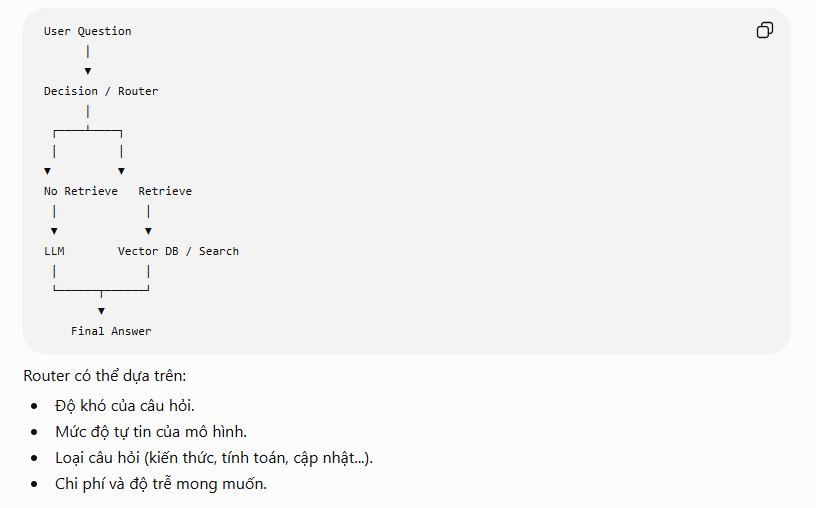

Adaptive RAG có thể "adaptive" ở nhiều mức

Không chỉ quyết định có retrieve hay không, mà còn có thể điều chỉnh:

Số lần retrieve
Retrieve 1 lần nếu đủ.
Nếu thông tin chưa đủ thì retrieve thêm.
Nguồn retrieve
Vector database.
Web search.
SQL database.
Knowledge graph.
API.
Số lượng document
Top-3
Top-10
Top-20
tùy mức độ khó của câu hỏi.
Chiến lược sinh câu trả lời
Trả lời trực tiếp.
Retrieve → Generate.
Retrieve → Reason → Retrieve tiếp → Generate.

In [1]:
import os
from dotenv import load_dotenv
from langfuse.langchain import CallbackHandler

load_dotenv() ## aloading all the environment variable

langfuse_trace = CallbackHandler()


In [2]:
### Build Index

from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings
from langchain_ollama import OllamaEmbeddings


d:\coding\ai_learning\krishnaik\ultimate-rag-bootcamp\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\Admin\AppData\Local\Temp\ipykernel_25800\3758882180.py:4: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import WebBaseLoader
USER_AGENT environment variable not set, consider setting it to identify your requests.


In [3]:
 ## Set embeddings
embd = OllamaEmbeddings(
    model="nomic-embed-text"
)

# Docs to index
urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
    "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/",
]

# Load
docs = [WebBaseLoader(url).load() for url in urls]
docs_list = [item for sublist in docs for item in sublist]

# Split
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=500, chunk_overlap=50
)
doc_splits = text_splitter.split_documents(docs_list)

# Add to vectorstore
vectorstore=FAISS.from_documents(
    documents=doc_splits,
    embedding=OpenAIEmbeddings()
)

retriever=vectorstore.as_retriever()

In [4]:
### Router

from typing import Literal

from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_ollama import ChatOllama

from pydantic import BaseModel, Field

# Data model
class RouteQuery(BaseModel):
    """Route a user query to the most relevant datasource."""

    datasource: Literal["vectorstore", "web_search"] = Field(
        ...,
        description="Given a user question choose to route it to web search or a vectorstore.",
    )

# LLM with function call
# llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
# llm = ChatOllama(model="granite4", temperature=0)
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
structured_llm_router = llm.with_structured_output(RouteQuery)

# Prompt
system = """You are an expert at routing a user question to a vectorstore or web search.
The vectorstore contains documents related to agents, prompt engineering, and adversarial attacks.
Use the vectorstore for questions on these topics. Otherwise, use web-search."""
route_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "{question}"),
    ]
)

question_router = route_prompt | structured_llm_router

print(
    question_router.invoke(
        {"question": "Who won the Cricket world cup 2023 "},
        config={"callbacks": [langfuse_trace]}
    )
)


datasource='web_search'


In [5]:
print(
    question_router.invoke(
        {"question": "What are the types of agent memory? "},
        config={"callbacks": [langfuse_trace]}
    )
)


datasource='vectorstore'


In [6]:
### Retrieval Grader


# Data model
class GradeDocuments(BaseModel):
    """Binary score for relevance check on retrieved documents."""

    binary_score: str = Field(
        description="Documents are relevant to the question, 'yes' or 'no'"
    )


# LLM with function call
# llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
llm = ChatOllama(model="granite4", temperature=0)
structured_llm_grader = llm.with_structured_output(GradeDocuments)

# Prompt
system = """You are a grader assessing relevance of a retrieved document to a user question. \n 
    If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n
    It does not need to be a stringent test. The goal is to filter out erroneous retrievals. \n
    Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question."""
grade_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Retrieved document: \n\n {document} \n\n User question: {question}"),
    ]
)

retrieval_grader = grade_prompt | structured_llm_grader
question = "agent memory"
## context
docs = retriever.invoke(question, config={"callbacks": [langfuse_trace]})
doc_txt = docs[1].page_content
print(retrieval_grader.invoke({"question": question, "document": doc_txt}))

binary_score='yes'


In [7]:
### Generate
# from langchain import hub
from langchain_core.output_parsers import StrOutputParser

# Prompt
# prompt = hub.pull("rlm/rag-prompt")

# LLM
# llm = ChatOpenAI(model_name="gpt-4o-mini", temperature=0)
# llm = ChatOllama(model="granite4", temperature=0)
llm = ChatOpenAI(model="gpt-4.1-nano", temperature=0)

prompt = ChatPromptTemplate.from_messages([
    ("human",
        "You are an assistant for question-answering tasks. Use the following pieces "
        "of retrieved context to answer the question. If you don't know the answer, "
        "just say that you don't know. Use three sentences maximum and keep the "
        "answer concise.\n"
        "Question: {question}\nContext: {context}\nAnswer:")
])

# Post-processing
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)


# Chain
rag_chain = prompt | llm | StrOutputParser()

# Run
generation = rag_chain.invoke({"context": docs, "question": question}, config={'callbacks': [langfuse_trace]})
print(generation)

Agent memory includes short-term memory, which is based on in-context learning within the model's finite context window, and long-term memory, which is often managed via external vector stores for extended information retention and retrieval. Short-term memory is used for immediate task processing, while long-term memory allows agents to recall and utilize information over extended periods. External memory modules, such as vector databases, enable fast retrieval through techniques like approximate nearest neighbors search.


In [8]:
### Hallucination Grader


# Data model
class GradeHallucinations(BaseModel):
    """Binary score for hallucination present in generation answer."""

    binary_score: str = Field(
        description="Answer is grounded in the facts, 'yes' or 'no'"
    )


# LLM with function call
# llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
# llm = ChatOllama(model="granite4", temperature=0)
llm = ChatOpenAI(model="gpt-4.1-nano", temperature=0)
structured_llm_grader = llm.with_structured_output(GradeHallucinations)

# Prompt
system = """You are a grader assessing whether an LLM generation is grounded in / supported by a set of retrieved facts. \n 
     Give a binary score 'yes' or 'no'. 'Yes' means that the answer is grounded in / supported by the set of facts."""
hallucination_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Set of facts: \n\n {documents} \n\n LLM generation: {generation}"),
    ]
)

hallucination_grader = hallucination_prompt | structured_llm_grader
hallucination_grader.invoke({"documents": docs, "generation": generation}, config={"callbacks": [langfuse_trace]})

GradeHallucinations(binary_score='yes')

In [9]:
### Answer Grader


# Data model
class GradeAnswer(BaseModel):
    """Binary score to assess answer addresses question."""

    binary_score: str = Field(
        description="Answer addresses the question, 'yes' or 'no'"
    )


# LLM with function call
# llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
# llm = ChatOllama(model="granite4", temperature=0)
llm = ChatOpenAI(model="gpt-4.1-nano", temperature=0)
structured_llm_grader = llm.with_structured_output(GradeAnswer)

# Prompt
system = """You are a grader assessing whether an answer addresses / resolves a question \n 
     Give a binary score 'yes' or 'no'. Yes' means that the answer resolves the question."""
answer_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "User question: \n\n {question} \n\n LLM generation: {generation}"),
    ]
)

answer_grader = answer_prompt | structured_llm_grader
answer_grader.invoke({"question": question, "generation": generation}, config={"callbacks": [langfuse_trace]})

GradeAnswer(binary_score='yes')

In [10]:
### Question Re-writer

# LLM
llm = ChatOpenAI(model="gpt-4.1-nano", temperature=0)
# llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
# llm = ChatOllama(model="granite4", temperature=0)

# Prompt
system = """You a question re-writer that converts an input question to a better version that is optimized \n 
     for vectorstore retrieval. Look at the input and try to reason about the underlying semantic intent / meaning."""
re_write_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        (
            "human",
            "Here is the initial question: \n\n {question} \n Formulate an improved question.",
        ),
    ]
)

question_rewriter = re_write_prompt | llm | StrOutputParser()
question_rewriter.invoke({"question": question}, config={"callbacks": [langfuse_trace]})

'How does agent memory function and what are its key components?'

In [11]:
from langchain_tavily import TavilySearch

web_search_tool = TavilySearch(max_results=2)

In [12]:
from typing import List
from typing_extensions import TypedDict


class GraphState(TypedDict):
    """
    Represents the state of our graph.

    Attributes:
        question: question
        generation: LLM generation
        documents: list of documents
    """

    question: str
    generation: str
    documents: List[str]

In [13]:
from langchain_core.documents import Document


def retrieve(state):
    print("---RETRIEVE---")
    question = state["question"]
    documents = retriever.invoke(question, config={"callbacks": [langfuse_trace]})
    return {"documents": documents, "question": question}


def generate(state):
    print("---GENERATE---")
    question = state["question"]
    documents = state["documents"]
    generation = rag_chain.invoke({"context": documents, "question": question}, config={"callbacks": [langfuse_trace]})
    return {"documents": documents, "question": question, "generation": generation}


def grade_documents(state):
    print("---CHECK DOCUMENT RELEVANCE TO QUESTION---")
    question = state["question"]
    documents = state["documents"]

    filtered_docs = []
    for d in documents:
        score = retrieval_grader.invoke(
            {"question": question, "document": d.page_content},
            config={"callbacks": [langfuse_trace]}
        )
        grade = score.binary_score
        if grade == "yes":
            print("---GRADE: DOCUMENT RELEVANT---")
            filtered_docs.append(d)
        else:
            print("---GRADE: DOCUMENT NOT RELEVANT---")
            continue
    return {"documents": filtered_docs, "question": question}


def transform_query(state):
    print("---TRANSFORM QUERY---")
    question = state["question"]
    documents = state["documents"]
    better_question = question_rewriter.invoke({"question": question}, config={"callbacks": [langfuse_trace]})
    return {"documents": documents, "question": better_question}


def web_search(state):
    print("---WEB SEARCH---")
    question = state["question"]

    docs = web_search_tool.invoke({"query": question}, config={"callbacks": [langfuse_trace]})

    # TavilySearch mới trả về string, cũ trả về list of dicts
    if isinstance(docs, str):
        web_results = docs
    elif isinstance(docs, list):
        if docs and isinstance(docs[0], dict):
            web_results = "\n".join([d["content"] for d in docs])
        else:
            web_results = "\n".join(docs)
    else:
        web_results = str(docs)

    web_results = Document(page_content=web_results)
    return {"documents": web_results, "question": question}


### Edges ###


def route_question(state):
    print("---ROUTE QUESTION---")
    question = state["question"]
    source = question_router.invoke({"question": question}, config={"callbacks": [langfuse_trace]})
    if source.datasource == "web_search":
        print("---ROUTE QUESTION TO WEB SEARCH---")
        return "web_search"
    elif source.datasource == "vectorstore":
        print("---ROUTE QUESTION TO RAG---")
        return "vectorstore"


def decide_to_generate(state):
    print("---ASSESS GRADED DOCUMENTS---")
    filtered_documents = state["documents"]

    if not filtered_documents:
        print("---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---")
        return "transform_query"
    else:
        print("---DECISION: GENERATE---")
        return "generate"


def grade_generation_v_documents_and_question(state):
    print("---CHECK HALLUCINATIONS---")
    question = state["question"]
    documents = state["documents"]
    generation = state["generation"]

    score = hallucination_grader.invoke(
        {"documents": documents, "generation": generation},
        config={"callbacks": [langfuse_trace]}
    )
    grade = score.binary_score

    if grade == "yes":
        print("---DECISION: GENERATION IS GROUNDED IN DOCUMENTS---")
        print("---GRADE GENERATION vs QUESTION---")
        score = answer_grader.invoke({"question": question, "generation": generation})
        grade = score.binary_score
        if grade == "yes":
            print("---DECISION: GENERATION ADDRESSES QUESTION---")
            return "useful"
        else:
            print("---DECISION: GENERATION DOES NOT ADDRESS QUESTION---")
            return "not useful"
    else:
        print("---DECISION: GENERATION IS NOT GROUNDED IN DOCUMENTS, RE-TRY---")
        return "not supported"

In [14]:
from langgraph.graph import END, StateGraph, START

workflow = StateGraph(GraphState)

# Define the nodes
workflow.add_node("web_search", web_search)  # web search
workflow.add_node("retrieve", retrieve)  # retrieve
workflow.add_node("grade_documents", grade_documents)  # grade documents
workflow.add_node("generate", generate)  # generate
workflow.add_node("transform_query", transform_query)  # transform_query

# Build graph
workflow.add_conditional_edges(
    START,
    route_question,
    {
        "web_search": "web_search",
        "vectorstore": "retrieve",
    },
)
workflow.add_edge("web_search", "generate")
workflow.add_edge("retrieve", "grade_documents")
workflow.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "transform_query": "transform_query",
        "generate": "generate",
    },
)
workflow.add_edge("transform_query", "web_search")  # fix: khi docs không relevant → rewrite query → web search
workflow.add_conditional_edges(
    "generate",
    grade_generation_v_documents_and_question,
    {
        "not supported": "generate",
        "useful": END,
        "not useful": "transform_query",
    },
)

# Compile
app = workflow.compile()

In [15]:
app.invoke({"question":"Who won the Cricket world cup 2023?"}, config={"callbacks": [langfuse_trace]})

---ROUTE QUESTION---
---ROUTE QUESTION TO WEB SEARCH---
---WEB SEARCH---
---GENERATE---
---CHECK HALLUCINATIONS---
---DECISION: GENERATION IS GROUNDED IN DOCUMENTS---
---GRADE GENERATION vs QUESTION---
---DECISION: GENERATION ADDRESSES QUESTION---


{'question': 'Who won the Cricket world cup 2023?',
 'generation': 'Australia won the 2023 ICC Cricket World Cup, defeating India in the final by 6 wickets. The final was held on November 19, 2023.',
 'documents': Document(metadata={}, page_content='{\'query\': \'Who won the Cricket world cup 2023?\', \'follow_up_questions\': None, \'answer\': None, \'images\': [], \'results\': [{\'url\': \'https://www.quora.com/Which-country-won-the-ICC-Cricket-World-Cup-2023\', \'title\': \'Which country won the ICC Cricket World Cup 2023? - Quora\', \'content\': "Australia won the 2023 ICC Men\'s Cricket World Cup, defeating India in the final by 6 wickets. The match was held on November 19, 2023,", \'score\': 0.95067275, \'raw_content\': None}, {\'url\': \'https://www.cricinfo.com/series/icc-cricket-world-cup-2023-24-1367856\', \'title\': \'ICC Cricket World Cup 2023/24 Fixtures, Live Score, Schedule, Points Table & News\', \'content\': "India A in Sri Lanka (1). Women\'s T20 World Cup (3). ICC Cri

In [16]:
app.invoke({"question":"What is agent memory"})

---ROUTE QUESTION---
---ROUTE QUESTION TO RAG---
---RETRIEVE---
---CHECK DOCUMENT RELEVANCE TO QUESTION---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---ASSESS GRADED DOCUMENTS---
---DECISION: GENERATE---
---GENERATE---
---CHECK HALLUCINATIONS---
---DECISION: GENERATION IS GROUNDED IN DOCUMENTS---
---GRADE GENERATION vs QUESTION---
---DECISION: GENERATION ADDRESSES QUESTION---


{'question': 'What is agent memory',
 'generation': "Agent memory refers to the system's ability to retain and recall information, which includes short-term memory (in-context learning within the model's finite context window) and long-term memory (external storage like vector databases with fast retrieval). Short-term memory is limited and used for immediate tasks, while long-term memory can store extensive information over time. External memory modules, such as vector stores, enable agents to access and utilize long-term information effectively.",
 'documents': [Document(id='fb3001ae-7ec6-4322-9b9a-fc06c08f410a', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond